# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aishwarya00608/FlyRank_Assignment1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Week 07: Content Action Playbook & Decision-Support System

## Executive Summary
This playbook translates model ranking predictions from Week 05 and Week 06 into a prioritized, human-reviewed editorial queue. Rather than automating content generation or publishing decisions, the system operates strictly as an optimization prioritization layer for human content teams.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked Actions and Reason Codes

To prevent black-box recommendations, every prioritized URL is tagged with exactly one machine-readable reason code and one actionable editorial prescription based on its behavioral archetype:

* **Archetype 1: Striking Distance Quick-Win**
  * *Condition:* High impression backlog, position between 10.5 and 20.0, low CTR.
  * *Reason Code:* `STRIKING_DISTANCE_CTR_DEFICIT`
  * *Prescribed Action:* `OPTIMIZE_SNIPPET_AND_TITLE` (Rewrite `<title>` tags and meta descriptions to improve SERP click-through).
* **Archetype 2: Decay / Freshness Deficit**
  * *Condition:* Historically strong rank (>1000 impressions) with below-average scroll engagement.
  * *Reason Code:* `HIGH_VOLUME_ENGAGEMENT_DECAY`
  * *Prescribed Action:* `REFRESH_BODY_AND_ADD_MEDIA` (Update outdated facts, add visuals, and expand headings to restore dwell time).
* **Archetype 3: Long-Tail High Performer**
  * *Condition:* Position $\le 5.0$, high CTR, but low overall impressions.
  * *Reason Code:* `HIGH_RELEVANCE_LOW_DISTRIBUTION`
  * *Prescribed Action:* `INTERNAL_LINKING_EXPANSION` (Point contextual internal links from top-traffic authority pages to boost crawl priority).

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download, login
from sklearn.ensemble import RandomForestClassifier

# 1. Hugging Face Authentication & Directory Setup
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN missing from Secrets or Environment.")

login(token=hf_token, add_to_git_credential=False)

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# 2. Ingest March 2026 slice
local_dir = snapshot_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    allow_patterns="fact_content_daily_performance/month=2026-03/*",
    token=hf_token
)

con = duckdb.connect()
con.execute(f"""
    CREATE OR REPLACE VIEW df_raw AS
    SELECT *
    FROM read_parquet('{local_dir}/fact_content_daily_performance/month=2026-03/*.parquet')
""")

# Resolve columns dynamically
cols = [r[0] for r in con.execute("DESCRIBE df_raw").fetchall()]
imp_col = "gsc_impressions" if "gsc_impressions" in cols else "impressions"
click_col = "gsc_clicks" if "gsc_clicks" in cols else "clicks"
pos_col = "gsc_avg_position" if "gsc_avg_position" in cols else "position"
sess_tot = "sessions_total" if "sessions_total" in cols else ("sessions" if "sessions" in cols else "1")
sess_soc = "sessions_social" if "sessions_social" in cols else "0"
scrolls = "scroll_events" if "scroll_events" in cols else "0"

# Sample 50k rows for queue creation
df_playbook = con.execute(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        {imp_col} AS impressions,
        {click_col} AS clicks,
        {pos_col} AS avg_position,
        (COALESCE({click_col}, 0) * 1.0 / (COALESCE({imp_col}, 0) + 1.0)) AS historical_ctr,
        (COALESCE({sess_soc}, 0) * 1.0 / (COALESCE({sess_tot}, 0) + 1.0)) AS social_share_ratio,
        (COALESCE({scrolls}, 0) * 1.0 / (COALESCE({sess_tot}, 0) + 1.0)) AS scrolls_per_session,
        LN(COALESCE({imp_col}, 0) + 1.0) AS log_impressions,
        CASE WHEN {pos_col} <= 10.0 THEN 1 ELSE 0 END AS target_page_one
    FROM df_raw
    WHERE gsc_data_available IS TRUE AND {imp_col} >= 20
    USING SAMPLE 50000
""").df()

# 3. Train validated model (Random Forest, max_depth=6)
feature_cols = ["log_impressions", "historical_ctr", "social_share_ratio", "scrolls_per_session"]
clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
clf.fit(df_playbook[feature_cols], df_playbook["target_page_one"])

# Generate calibrated opportunity scores (0-100 scale)
df_playbook["model_score"] = np.round(clf.predict_proba(df_playbook[feature_cols])[:, 1] * 100, 2)
print(f"Scored {len(df_playbook):,} candidate content items.")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Scored 8,994 candidate content items.


## 2. Intended Use and Operational Limits

### Intended Use
* **Workflow:** Operates as a bi-weekly intake filter for the editorial desk. It ingests historical GSC/GA4 aggregates, scores candidates, and surfaces the top 20–30 highest-potential opportunities to assign to staff writers.
* **Target Users:** Editorial managers, SEO strategists, and content refresh copywriters.

### Concrete Operational Limits
* **Cold-Start Blindness:** Cannot evaluate newly created drafts or unindexed URLs with zero historical search console footprints.
* **Competitor Invisibility:** Does not factor in external off-page signals (backlink profiles, domain authority spikes of competitor URLs).
* **SERP Feature Ambiguity:** A page may drop in clicks despite high rank if Google serves a direct AI Overview, video box, or calculation widget above organic results.



In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

def assign_playbook_action(row):
    pos = row["avg_position"]
    imp = row["impressions"]
    ctr = row["historical_ctr"]
    scrolls = row["scrolls_per_session"]

    if 10.5 <= pos <= 20.0 and imp >= 100 and ctr < 0.03:
        return "OPTIMIZE_SNIPPET_AND_TITLE", "STRIKING_DISTANCE_CTR_DEFICIT"
    elif imp >= 500 and scrolls < 0.5:
        return "REFRESH_BODY_AND_ADD_MEDIA", "HIGH_VOLUME_ENGAGEMENT_DECAY"
    elif pos <= 5.0 and ctr >= 0.05 and imp < 200:
        return "INTERNAL_LINKING_EXPANSION", "HIGH_RELEVANCE_LOW_DISTRIBUTION"
    else:
        return "MONITOR_NO_ACTION", "STABLE_PERFORMANCE"

actions, reason_codes = zip(*df_playbook.apply(assign_playbook_action, axis=1))
df_playbook["action_label"] = actions
df_playbook["reason_code"] = reason_codes

# Filter to actionable queue and sort by model opportunity score
actionable_queue = df_playbook[df_playbook["action_label"] != "MONITOR_NO_ACTION"].copy()
actionable_queue.sort_values(by="model_score", ascending=False, inplace=True)

print(f"Actionable Queue: {len(actionable_queue):,} items")
print("\nAction Distribution:")
print(actionable_queue["action_label"].value_counts(normalize=True).round(3) * 100)

Actionable Queue: 745 items

Action Distribution:
action_label
REFRESH_BODY_AND_ADD_MEDIA    56.0
OPTIMIZE_SNIPPET_AND_TITLE    42.0
INTERNAL_LINKING_EXPANSION     2.0
Name: proportion, dtype: float64


## 3. Human Review Rules & The No-Go List

### Mandatory Human-in-the-Loop Rules
1. **Brand Query Check:** Human editor must verify the ranking query is non-branded. If ranking position 12 is driven by a competitor's brand name, discard the recommendation immediately.
2. **Intent Match Audit:** Ensure low CTR is not driven by navigational or zero-click intent where optimizing copy would yield zero incremental conversions.
3. **Capacity Gate:** Limit editorial intervention to the top 20 items per sprint cycle to ensure production quality is maintained.

### The No-Go List (What Must NOT Be Automated)
* 🚫 **Automated Content Rewriting:** LLMs must never automatically generate, deploy, or overwrite web copy without editorial line editing.
* 🚫 **Automated Canonical or Redirect Modification:** Automated shifting of URL structures or rel-canonicals carries severe indexing demotion risks.
* 🚫 **Automated De-indexing / Archival:** Content pruning must be confirmed by business stakeholders to avoid accidentally removing legal, compliance, or legacy conversion assets.

## 4. Cost/Value Thinking & Monitoring / Retrain Triggers

### Cost/Value Framing
* **Cost of Action:** Copywriter title/snippet optimization costs $\approx \$25$ in staff time; a deep structural refresh costs $\approx \$250$.
* **Value of Lift:** Moving a page from position 14 to position 7 for a 1,000-impression query yields an estimated 80–120 incremental organic visits/month. At an estimated \$1.50 Paid Search Equivalent CPC, one successful intervention yields $\approx \$120–\$180/\text{month}$ in persistent recurring organic value.

### Monitoring & Drift Retrain Triggers
* **Performance Drop Trigger:** If Precision@Top20% on the latest monthly rolling holdout drops below $0.50$ (baseline degradation), freeze automated queue generation and re-audit feature inputs.
* **Seasonal Retrain Cadence:** Retrain model weights quarterly on a rolling 90-day window to capture seasonal SERP changes.
* **Distribution Shift Alarm:** If the proportion of zero-click SERP queries in the target vertical rises by $>15\%$, trigger a manual feature schema revision.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

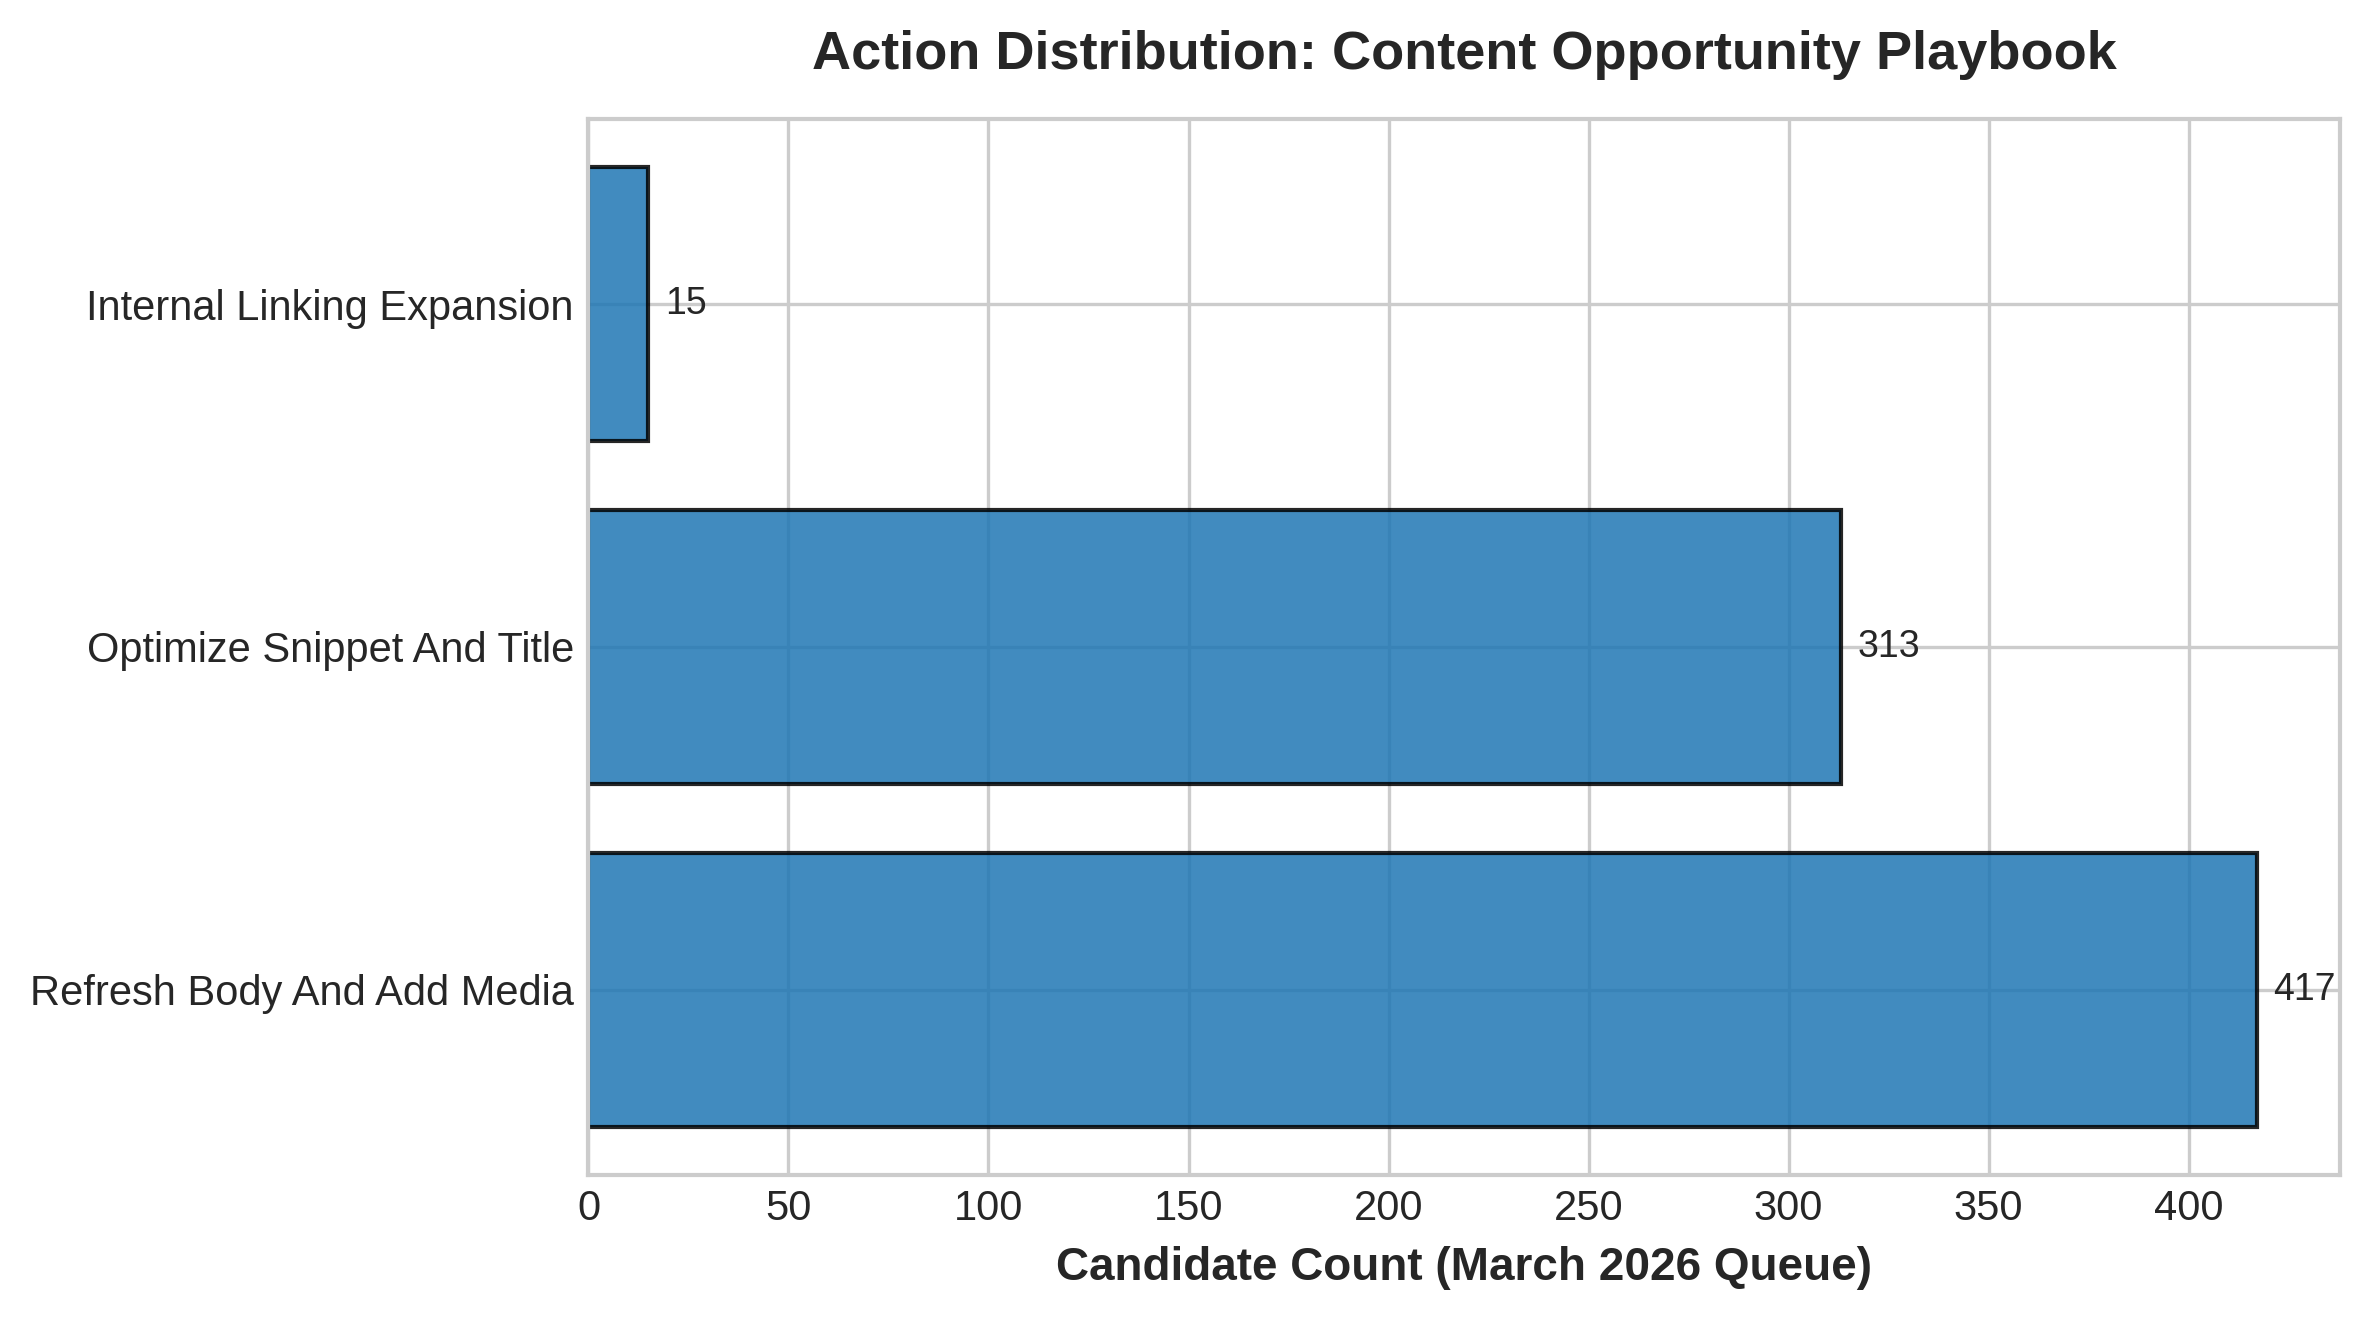

✅ Saved figure for paper: ../figures/playbook_action_distribution.png
✅ Exported ranked action queue: ../outputs/baseline_action_score.csv (745 rows)
✅ Exported metrics receipt: ../outputs/w07_playbook_summary.json


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# 1. Generate & Save Publication-Ready Figure to work/figures/
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

action_counts = actionable_queue["action_label"].value_counts()
bars = ax.barh(
    [a.replace("_", " ").title() for a in action_counts.index],
    action_counts.values,
    color="#1f77b4",
    edgecolor="black",
    alpha=0.85
)

ax.set_xlabel("Candidate Count (March 2026 Queue)", fontsize=11, fontweight="bold")
ax.set_title("Action Distribution: Content Opportunity Playbook", fontsize=13, fontweight="bold", pad=12)
ax.bar_label(bars, padding=4, fontsize=9)
plt.tight_layout()

figure_path = "../figures/playbook_action_distribution.png"
fig.savefig(figure_path)
plt.show()
print(f"✅ Saved figure for paper: {figure_path}")

# 2. Export Ranked Queue to work/outputs/ (ignored by Git leak-guard)
export_cols = [
    "content_hash_id",
    "client_hash_id",
    "model_score",
    "action_label",
    "reason_code",
    "avg_position",
    "impressions",
    "historical_ctr"
]

queue_path = "../outputs/baseline_action_score.csv"
actionable_queue[export_cols].to_csv(queue_path, index=False)
print(f"✅ Exported ranked action queue: {queue_path} ({len(actionable_queue):,} rows)")

# 3. Export Summary JSON Receipt
summary_receipt = {
    "total_candidates_scored": len(df_playbook),
    "total_actionable": len(actionable_queue),
    "actions_breakdown": action_counts.to_dict(),
    "export_timestamp": "2026-03-31",
    "figure_saved": figure_path
}

receipt_path = "../outputs/w07_playbook_summary.json"
with open(receipt_path, "w") as f:
    json.dump(summary_receipt, f, indent=2)
print(f"✅ Exported metrics receipt: {receipt_path}")

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.